In [87]:
import pandas as pd
import datetime as dt
import holidays
import matplotlib.pyplot as plt
import numpy as np
import json
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [88]:
df = pd.read_csv('/Users/cleolaurindo/Downloads/Meta_Learner/07_chlamydia_selected_states_weekly_wide.csv')

In [89]:
df.head()

,date,Alabama,Alaska,Arizona,California,Florida,Idaho,Kansas,Kentucky,Louisiana,...,New York,Oklahoma,Oregon,Pennsylvania,South Carolina,Utah,Virginia,Washington,West Virginia,Wisconsin
0,2022-01-03,333.0,NaN,347.0,235.0,629.0,NaN,23.0,21.0,NaN,...,293.0,NaN,327.0,665.0,551.0,147.0,506.0,308.0,25.0,127.0
1,2022-01-10,114.0,NaN,365.0,NaN,NaN,5.0,22.0,125.0,NaN,...,425.0,31.0,129.0,NaN,309.0,69.0,NaN,232.0,NaN,61.0
2,2022-01-17,75.0,NaN,NaN,NaN,NaN,NaN,29.0,NaN,NaN,...,486.0,31.0,NaN,NaN,NaN,149.0,739.0,220.0,13.0,NaN
3,2022-01-24,NaN,NaN,471.0,NaN,NaN,NaN,35.0,NaN,NaN,...,802.0,51.0,NaN,948.0,NaN,NaN,814.0,234.0,NaN,NaN
4,2022-01-31,62.0,NaN,460.0,640.0,1474.0,NaN,18.0,NaN,NaN,...,808.0,26.0,47.0,921.0,203.0,164.0,876.0,334.0,25.0,NaN


In [90]:
for c in df.columns:
    print(f"{c}: {df[c].isna().sum()}")

date: 0
Alabama: 3
Alaska: 30
Arizona: 20
California: 22
Florida: 24
Idaho: 12
Kansas: 20
Kentucky: 5
Louisiana: 20
Maine: 12
Michigan: 8
Minnesota: 23
Mississippi: 29
Montana: 17
New Mexico: 27
New York: 8
Oklahoma: 10
Oregon: 2
Pennsylvania: 7
South Carolina: 9
Utah: 7
Virginia: 8
Washington: 8
West Virginia: 18
Wisconsin: 5


In [91]:
l = []

for col in df.columns[1:]:
    temp = pd.DataFrame()
    temp["date"] = df["date"]
    temp["cases"] = df[col]
    temp["state"] = col
    l.append(temp)

dg = pd.concat(l, ignore_index=True)

    

In [92]:
dg

,date,cases,state
0,2022-01-03,333.0,Alabama
1,2022-01-10,114.0,Alabama
2,2022-01-17,75.0,Alabama
3,2022-01-24,NaN,Alabama
4,2022-01-31,62.0,Alabama
...,...,...,...
5670,2026-04-13,326.0,Wisconsin
5671,2026-04-20,369.0,Wisconsin
5672,2026-04-27,347.0,Wisconsin
5673,2026-05-04,347.0,Wisconsin


In [93]:
dg.isna().sum()

date       0
cases    354
state      0
dtype: int64

In [94]:
dg.shape

(5675, 3)

In [95]:
df=dg

In [96]:
df.date= pd.to_datetime(df.date)
df['week'] = df.date.dt.isocalendar().week
df['year'] = df.date.dt.year - df.date.dt.year.min()
df['month'] = df.date.dt.month
df['quarter'] = df.date.dt.quarter
#  we will mark the whole week as a holiday week, create a new column called holiday and mark it as 1 if there was a holiday in that week and 0 if there was no holiday in that week
us_holidays = holidays.US()
df['holiday'] = df.apply(lambda x: 1 if any((x['date'] + pd.Timedelta(days=-i)) in us_holidays for i in range(7)) else 0, axis=1)

In [97]:
df.isna().sum()

date         0
cases      354
state        0
week         0
year         0
month        0
quarter      0
holiday      0
dtype: int64

In [98]:
df[df['cases']<1].shape

(0, 8)

In [99]:
# drop all NaN values that have at least 3 consecutive naN values in the cases column, otherwise, use interpolation to fill the NaN values
for state in df['state'].unique():
    state_data = df[df['state'] == state]
    if state_data['cases'].isna().rolling(window=3).sum().max() >= 3:
        df.loc[df['state'] == state, 'cases'].dropna(inplace=True)
    elif state_data['cases'].isna().sum() > 0:
        df.loc[df['state'] == state, 'cases'] = df.loc[df['state'] == state, 'cases'].interpolate()



In [100]:
df.isna().sum()

date         0
cases      262
state        0
week         0
year         0
month        0
quarter      0
holiday      0
dtype: int64

In [101]:
df.dropna(inplace=True)

In [102]:
population_dict = {
    'Alabama': 5157699,
    'Alaska': 740133,
    'Arizona': 7582384,
    'Arkansas': 3088354,
    'California': 39431263,
    'Colorado': 5957493,
    'Connecticut': 3675069,
    'Delaware': 1051917,
    'Florida': 23372215,
    'Georgia': 11180878,
    'Hawaii': 1446146,
    'Idaho': 2001619,
    'Illinois': 12710158,
    'Indiana': 6924275,
    'Iowa': 3241488,
    'Kansas': 2970606,
    'Kentucky': 4588372,
    'Louisiana': 4597740,
    'Maine': 1405012,
    'Maryland': 6263220,
    'Massachusetts': 7136171,
    'Michigan': 10140459,
    'Minnesota': 5793151,
    'Mississippi': 2943045,
    'Missouri': 6245466,
    'Montana': 1137233,
    'Nebraska': 2005465,
    'Nevada': 3267467,
    'New Hampshire': 1409032,
    'New Jersey': 9500851,
    'New Mexico': 2130256,
    'New York': 19867248,
    'North Carolina': 11046024,
    'North Dakota': 796568,
    'Ohio': 11883304,
    'Oklahoma': 4095393,
    'Oregon': 4272371,
    'Pennsylvania': 13078751,
    'Rhode Island': 1112308,
    'South Carolina': 5478831,
    'South Dakota': 924669,
    'Tennessee': 7227750,
    'Texas': 31290831,
    'Utah': 3503613,
    'Vermont': 648493,
    'Virginia': 8811195,
    'Washington': 7958180,
    'West Virginia': 1769979,
    'Wisconsin': 5960975,
    'Wyoming': 587618
}

In [103]:
# cases column divide by population of each state and multiply by 100000 to get the rate of cases per 100000 people, create a new column called cases_per_100k
df['cases_per_100k'] = df.apply(lambda x: (x['cases'] / population_dict[x['state']]) * 100000, axis=1)

In [104]:
df = df.sort_values(['state', 'date']).reset_index(drop=True)
state_rate = df.groupby('state')['cases_per_100k']

df['lagged1'] = state_rate.shift(1)
df['lagged2'] = state_rate.shift(2)
df['lagged4'] = state_rate.shift(4)
df['lagged6'] = state_rate.shift(6)
df['lagged8'] = state_rate.shift(8)
df['lagged12'] = df.groupby('state')['cases_per_100k'].shift(12)
df['rolling_mean_2'] = df.groupby('state')['cases_per_100k'].rolling(window=2, closed='left').mean().reset_index(0,drop=True)
df['rolling_mean_4'] = df.groupby('state')['cases_per_100k'].rolling(window=4, closed='left').mean().reset_index(0,drop=True)
df['rolling_mean_6'] = df.groupby('state')['cases_per_100k'].rolling(window=6, closed='left').mean().reset_index(0,drop=True)
df['rolling_mean_8'] = df.groupby('state')['cases_per_100k'].rolling(window=8, closed='left').mean().reset_index(0,drop=True)
df['rolling_mean_12'] = df.groupby('state')['cases_per_100k'].rolling(window=12, closed='left').mean().reset_index(0,drop=True) 
df['rolling_std_2'] = df.groupby('state')['cases_per_100k'].rolling(window=2, closed='left').std().reset_index(0,drop=True)
df['rolling_std_4'] = df.groupby('state')['cases_per_100k'].rolling(window=4, closed='left').std().reset_index(0,drop=True)
df['rolling_std_6'] = df.groupby('state')['cases_per_100k'].rolling(window=6, closed='left').std().reset_index(0,drop=True)
df['rolling_std_8'] = df.groupby('state')['cases_per_100k'].rolling(window=8, closed='left').std().reset_index(0,drop=True)
df['rolling_std_12'] = df.groupby('state')['cases_per_100k'].rolling(window=12, closed='left').std().reset_index(0,drop=True)
df['rolling_median_4'] = df.groupby('state')['cases_per_100k'].rolling(window=4, closed='left').median().reset_index(0,drop=True)
df['rolling_median_6'] = df.groupby('state')['cases_per_100k'].rolling(window=6, closed='left').median().reset_index(0,drop=True)
df['rolling_median_12'] = df.groupby('state')['cases_per_100k'].rolling(window=12, closed='left').median().reset_index(0,drop=True)
df['rolling_median_2'] = df.groupby('state')['cases_per_100k'].rolling(window=2, closed='left').median().reset_index(0,drop=True)
df['rolling_median_8'] = df.groupby('state')['cases_per_100k'].rolling(window=8, closed='left').median().reset_index(0,drop=True)
df['rolling_max_4'] = df.groupby('state')['cases_per_100k'].rolling(window=4, closed='left', min_periods=1).max().reset_index(0,drop=True)
df['rolling_max_6'] = df.groupby('state')['cases_per_100k'].rolling(window=6, closed='left', min_periods=1).max().reset_index(0,drop=True)
df['rolling_max_12'] = df.groupby('state')['cases_per_100k'].rolling(window=12, closed='left', min_periods=1).max().reset_index(0,drop=True)
df['rolling_max_8'] = df.groupby('state')['cases_per_100k'].rolling(window=8, closed='left', min_periods=1).max().reset_index(0,drop=True)
df['rolling_max_2'] = df.groupby('state')['cases_per_100k'].rolling(window=2, closed='left', min_periods=1).max().reset_index(0,drop=True)
df['rolling_min_4'] = df.groupby('state')['cases_per_100k'].rolling(window=4, closed='left', min_periods=1).min().reset_index(0,drop=True)
df['rolling_min_6'] = df.groupby('state')['cases_per_100k'].rolling(window=6, closed='left', min_periods=1).min().reset_index(0,drop=True)
df['rolling_min_12'] = df.groupby('state')['cases_per_100k'].rolling(window=12, closed='left', min_periods=1).min().reset_index(0,drop=True)
df['rolling_min_2'] = df.groupby('state')['cases_per_100k'].rolling(window=2, closed='left', min_periods=1).min().reset_index(0,drop=True)
df['rolling_min_8'] = df.groupby('state')['cases_per_100k'].rolling(window=8, closed='left', min_periods=1).min().reset_index(0,drop=True)
df['expanding_mean'] = state_rate.transform(lambda s: s.shift(1).expanding().mean())
df['expanding_std'] = state_rate.transform(lambda s: s.shift(1).expanding().std())
df['expanding_median'] = state_rate.transform(lambda s: s.shift(1).expanding().median())
df['expanding_max'] = state_rate.transform(lambda s: s.shift(1).expanding().max())
df['expanding_min'] = state_rate.transform(lambda s: s.shift(1).expanding().min())
df['ewm_mean'] = state_rate.transform(lambda s: s.shift(1).ewm(alpha=0.25, adjust=False).mean())
df['ewm_std'] = state_rate.transform(lambda s: s.shift(1).ewm(alpha=0.25, adjust=False).std())


In [105]:
df.drop(columns=['cases'],inplace=True)
df.isna().sum()

date                   0
state                  0
week                   0
year                   0
month                  0
quarter                0
holiday                0
cases_per_100k         0
lagged1               25
lagged2               50
lagged4              100
lagged6              150
lagged8              200
lagged12             300
rolling_mean_2        50
rolling_mean_4       100
rolling_mean_6       150
rolling_mean_8       200
rolling_mean_12      300
rolling_std_2         50
rolling_std_4        100
rolling_std_6        150
rolling_std_8        200
rolling_std_12       300
rolling_median_4     100
rolling_median_6     150
rolling_median_12    300
rolling_median_2      50
rolling_median_8     200
rolling_max_4         25
rolling_max_6         25
rolling_max_12        25
rolling_max_8         25
rolling_max_2         25
rolling_min_4         25
rolling_min_6         25
rolling_min_12        25
rolling_min_2         25
rolling_min_8         25
expanding_mean        25


In [106]:
for st in df.state.unique():
    print(f"State: {st}")
    print(df.loc[df['state'] == st,'cases_per_100k'].isna().sum())
    # drop state that have more than 3 consective nans in a row
    if df.loc[df['state'] == st,'cases_per_100k'].isna().rolling(window=4).sum().max() > 2:
        df = df[df['state'] != st]


State: Alabama
0
State: Alaska
0
State: Arizona
0
State: California
0
State: Florida
0
State: Idaho
0
State: Kansas
0
State: Kentucky
0
State: Louisiana
0
State: Maine
0
State: Michigan
0
State: Minnesota
0
State: Mississippi
0
State: Montana
0
State: New Mexico
0
State: New York
0
State: Oklahoma
0
State: Oregon
0
State: Pennsylvania
0
State: South Carolina
0
State: Utah
0
State: Virginia
0
State: Washington
0
State: West Virginia
0
State: Wisconsin
0


In [107]:
df.state.unique()

<StringArray>
[       'Alabama',         'Alaska',        'Arizona',     'California',
        'Florida',          'Idaho',         'Kansas',       'Kentucky',
      'Louisiana',          'Maine',       'Michigan',      'Minnesota',
    'Mississippi',        'Montana',     'New Mexico',       'New York',
       'Oklahoma',         'Oregon',   'Pennsylvania', 'South Carolina',
           'Utah',       'Virginia',     'Washington',  'West Virginia',
      'Wisconsin']
Length: 25, dtype: str

In [108]:
df.shape

(5413, 46)

In [109]:
df[df['state'].isin(['California','Arizona'])].loc[200:250,['ewm_mean','ewm_std','expanding_mean','expanding_std','expanding_median','expanding_max','expanding_min','lagged1','lagged2','lagged4','lagged8','rolling_mean_4','rolling_std_4']]

,ewm_mean,ewm_std,expanding_mean,expanding_std,expanding_median,expanding_max,expanding_min,lagged1,lagged2,lagged4,lagged8,rolling_mean_4,rolling_std_4


In [110]:
df.loc[200:250]

,date,state,week,year,month,quarter,holiday,cases_per_100k,lagged1,lagged2,...,rolling_min_12,rolling_min_2,rolling_min_8,expanding_mean,expanding_std,expanding_median,expanding_max,expanding_min,ewm_mean,ewm_std
200,2025-11-10,Alabama,46,3,11,4,0,10.857555,10.566728,11.962699,...,7.968670,10.566728,7.968670,10.952413,2.398579,11.225936,18.768059,1.202086,10.718738,1.206387
201,2025-11-17,Alabama,47,3,11,4,1,10.237123,10.857555,10.566728,...,7.968670,10.566728,7.968670,10.951941,2.392584,11.206548,18.768059,1.202086,10.753442,1.046777
202,2025-11-24,Alabama,48,3,11,4,0,11.574929,10.237123,10.857555,...,7.968670,10.237123,9.655468,10.948402,2.387155,11.196853,18.768059,1.202086,10.624363,0.938148
203,2025-12-01,Alabama,49,3,12,4,1,7.464569,11.574929,10.237123,...,7.968670,10.237123,9.752411,10.951489,2.381645,11.206548,18.768059,1.202086,10.862004,0.926147
204,2025-12-08,Alabama,50,3,12,4,0,9.713634,7.464569,11.574929,...,7.464569,7.464569,7.464569,10.934396,2.388282,11.196853,18.768059,1.202086,10.012645,1.779957
205,2025-12-15,Alabama,51,3,12,4,0,11.225936,9.713634,7.464569,...,7.464569,7.464569,7.464569,10.928441,2.383946,11.187159,18.768059,1.202086,9.937893,1.547819
206,2025-12-22,Alabama,52,3,12,4,0,11.225936,11.225936,9.713634,...,7.464569,9.713634,7.464569,10.929885,2.378215,11.196853,18.768059,1.202086,10.259903,1.469601
207,2025-12-29,Alabama,1,3,12,4,1,7.154353,11.225936,11.225936,...,7.464569,11.225936,7.464569,10.931315,2.372525,11.206548,18.768059,1.202086,10.501412,1.350532
208,2026-01-05,Alabama,2,4,1,1,1,13.533167,7.154353,11.225936,...,7.154353,7.154353,7.154353,10.913157,2.381232,11.196853,18.768059,1.202086,9.664647,1.954115
209,2026-01-12,Alabama,3,4,1,1,0,11.497375,13.533167,7.154353,...,7.154353,7.154353,7.154353,10.925693,2.382404,11.206548,18.768059,1.202086,10.631777,2.477421


In [111]:
# transform into csv file, w/o one hot encoding the state column, we will do that in the modeling phase if necessary
df.to_csv('/Users/cleolaurindo/Downloads/Meta_Learner/preprocessed_No_OHE.csv', index=False)

# Use one hot encoder whenever sklearn is used!

In [112]:
# now do one hot encoding for the state column and save it as a new csv file called preprocessed_OHE.csv
df_ohe = pd.get_dummies(df, columns=['state'])
df_ohe.to_csv('/Users/cleolaurindo/Downloads/Meta_Learner/preprocessed_OHE.csv', index=False)
# what is to_csv(index=False) do? it means that we don't want to save the index of the dataframe as a column in the csv file, if we set it to True, it will save the index as a column in the csv file, which we don't want in this case because we don't need the index for modeling, we just want the features and the target variable    

In [113]:
df.isna().sum()

date                   0
state                  0
week                   0
year                   0
month                  0
quarter                0
holiday                0
cases_per_100k         0
lagged1               25
lagged2               50
lagged4              100
lagged6              150
lagged8              200
lagged12             300
rolling_mean_2        50
rolling_mean_4       100
rolling_mean_6       150
rolling_mean_8       200
rolling_mean_12      300
rolling_std_2         50
rolling_std_4        100
rolling_std_6        150
rolling_std_8        200
rolling_std_12       300
rolling_median_4     100
rolling_median_6     150
rolling_median_12    300
rolling_median_2      50
rolling_median_8     200
rolling_max_4         25
rolling_max_6         25
rolling_max_12        25
rolling_max_8         25
rolling_max_2         25
rolling_min_4         25
rolling_min_6         25
rolling_min_12        25
rolling_min_2         25
rolling_min_8         25
expanding_mean        25


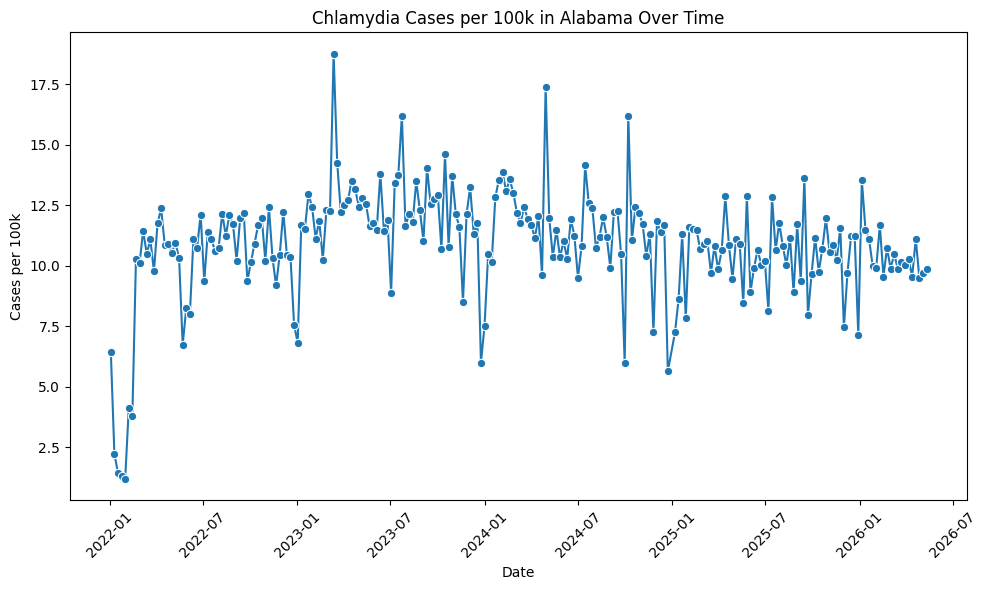

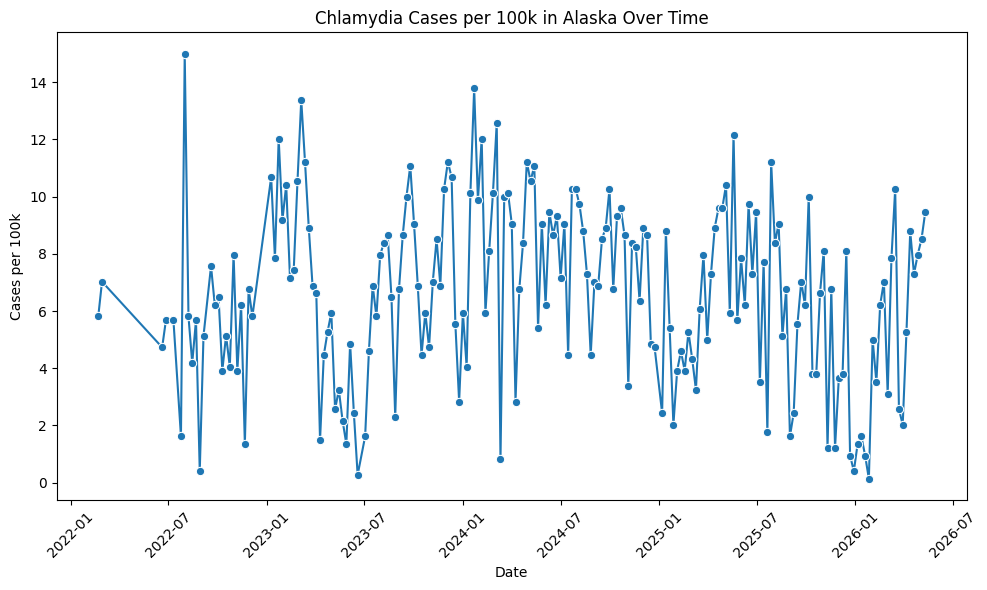

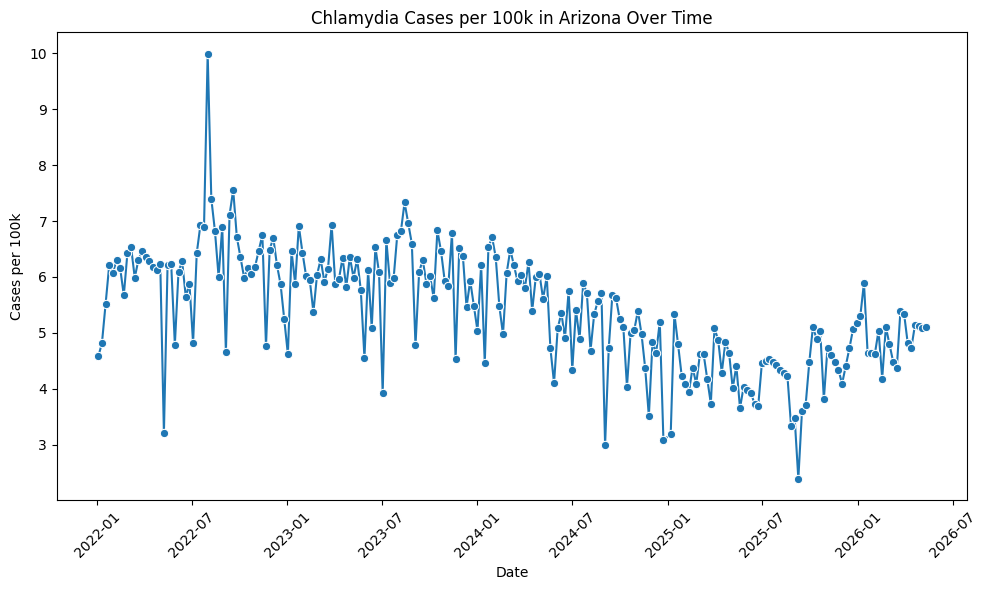

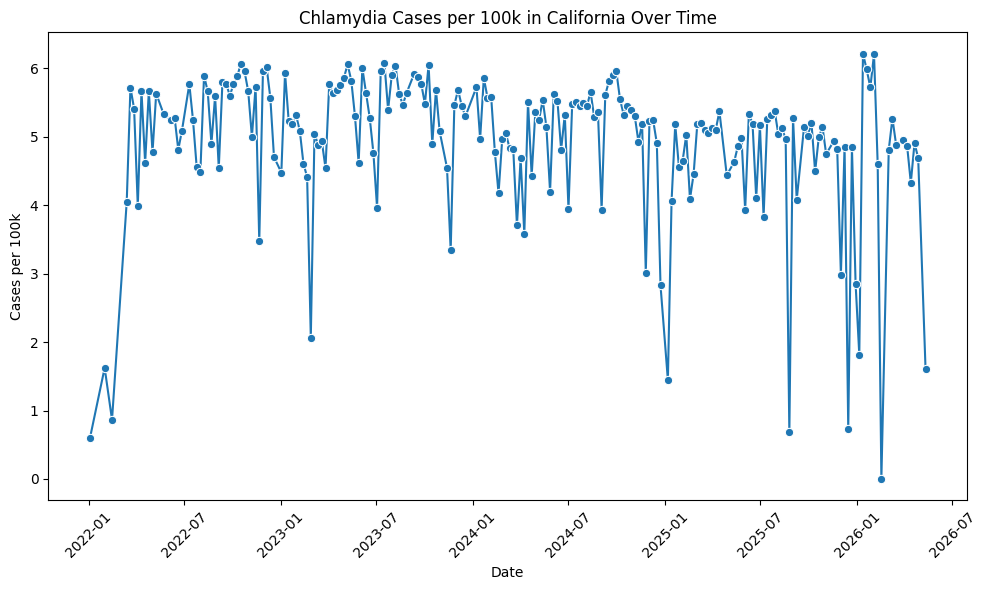

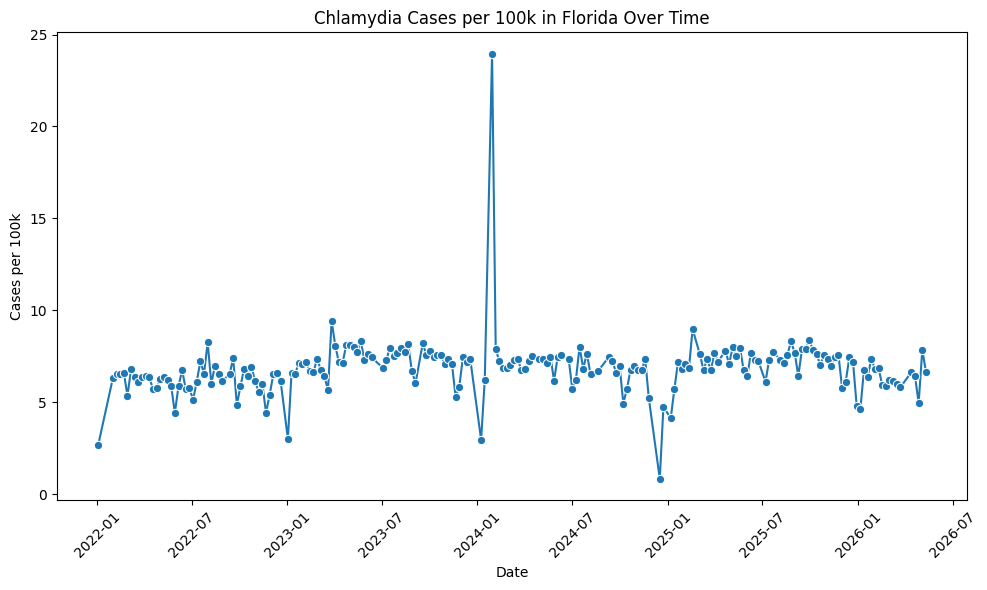

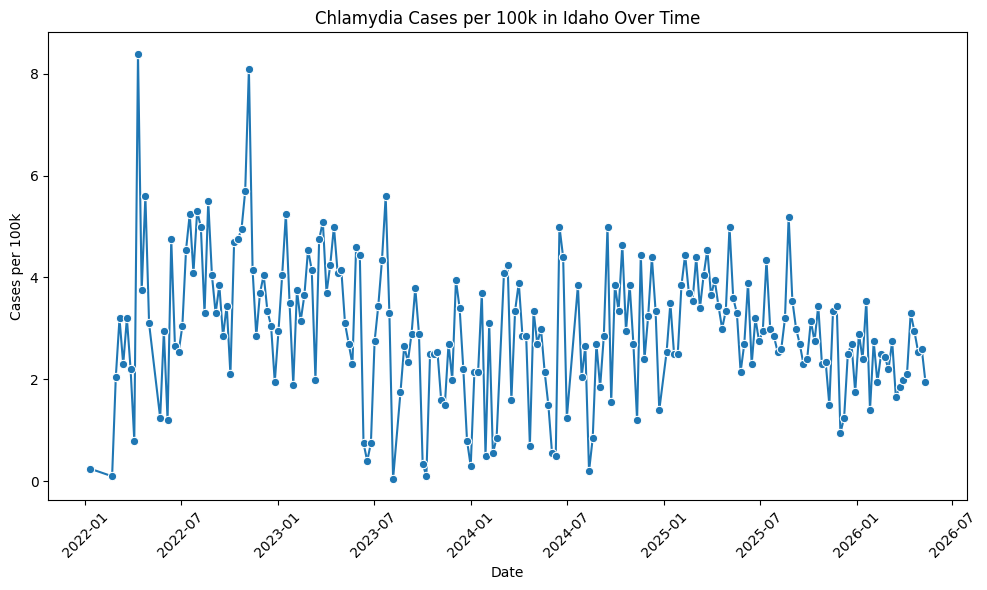

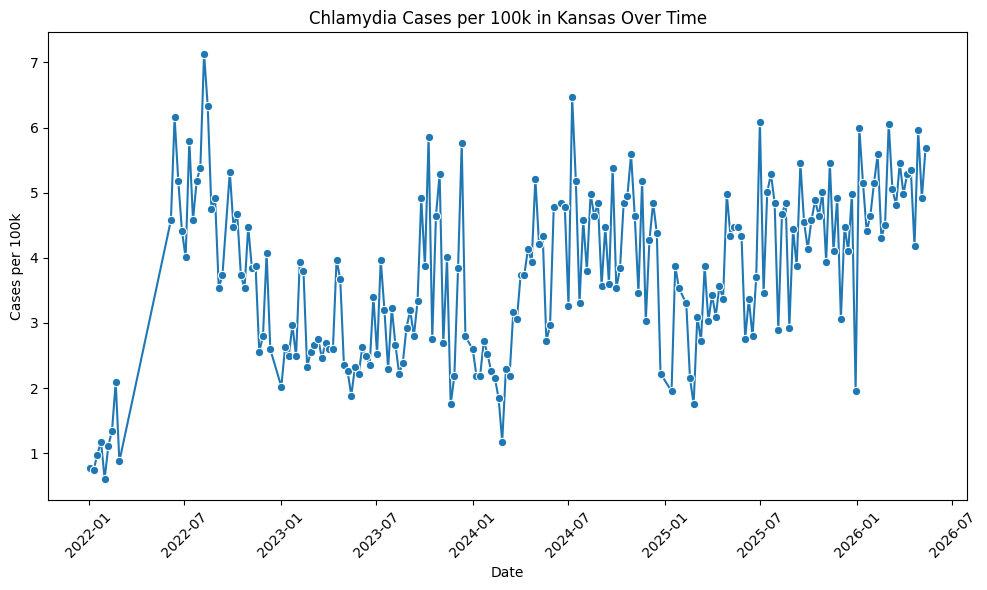

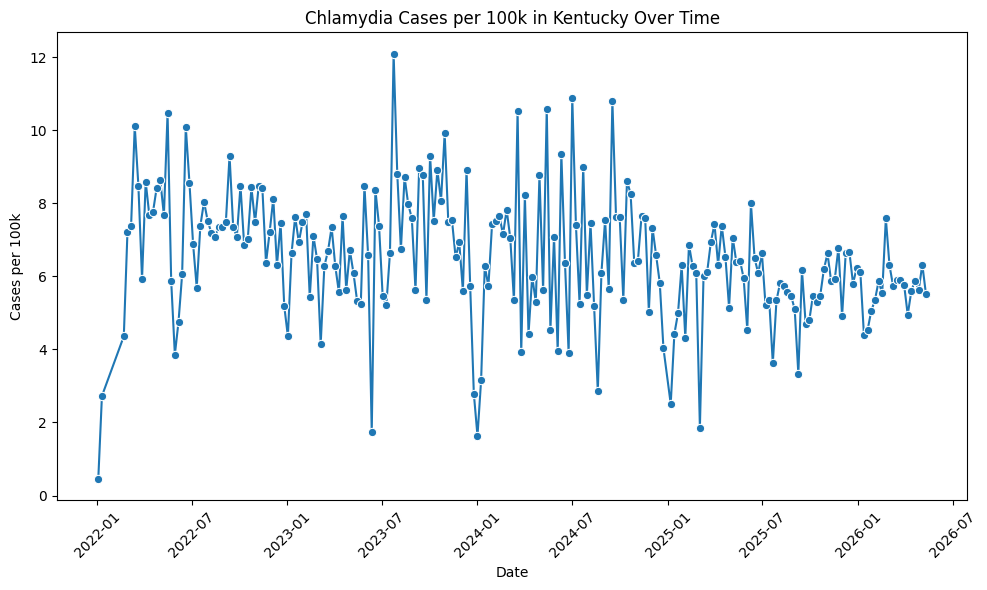

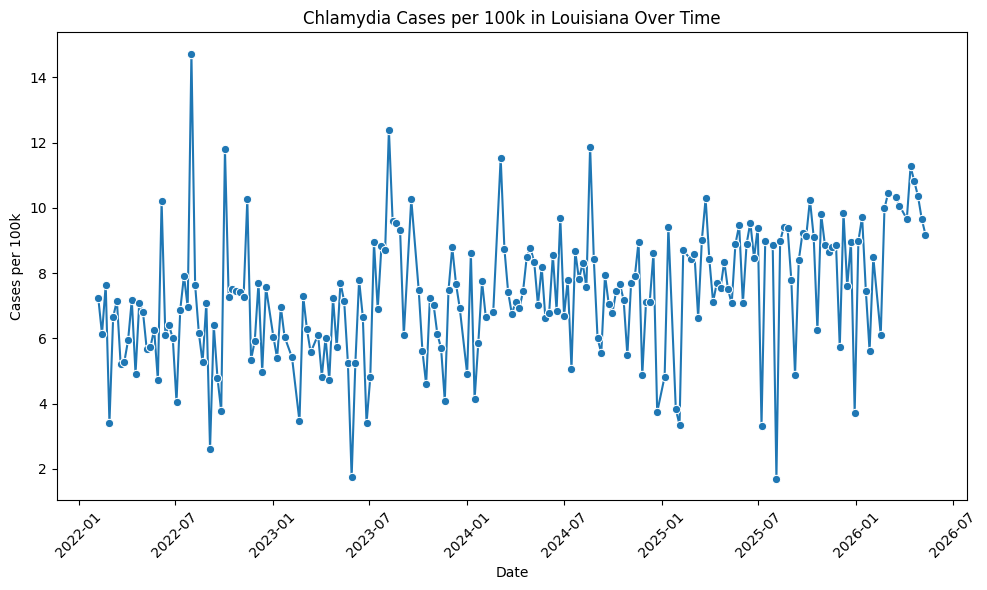

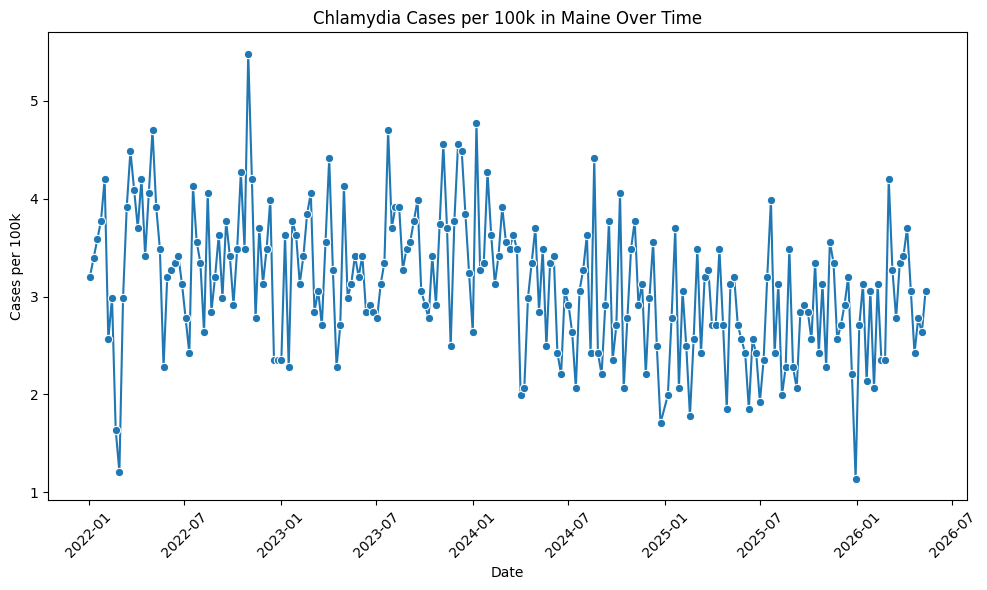

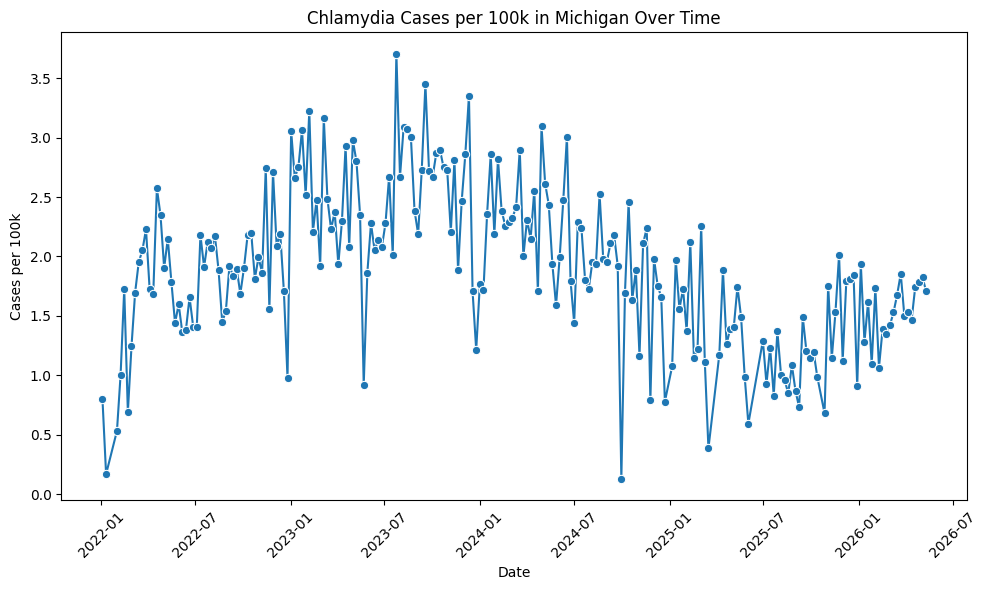

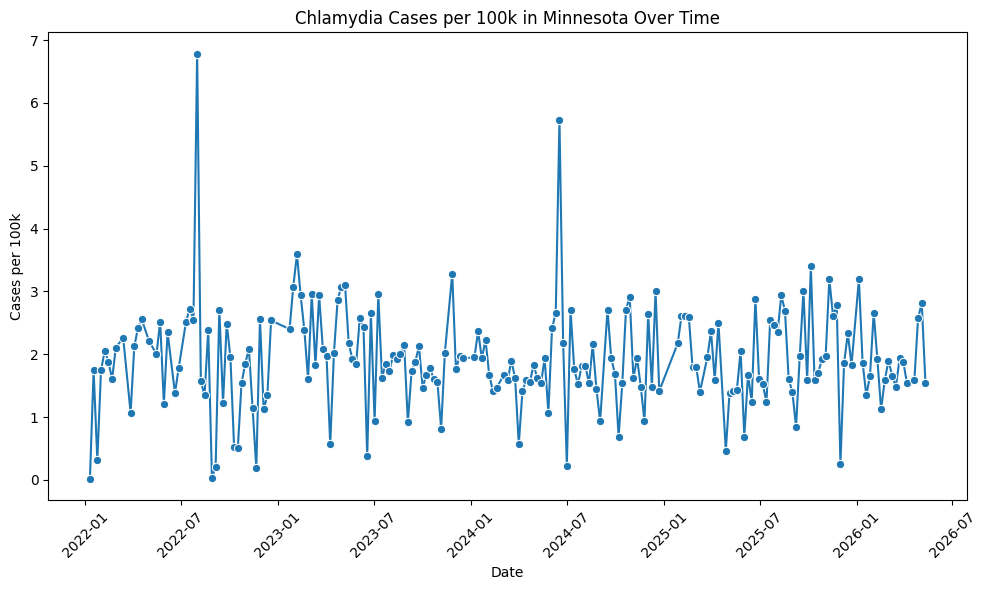

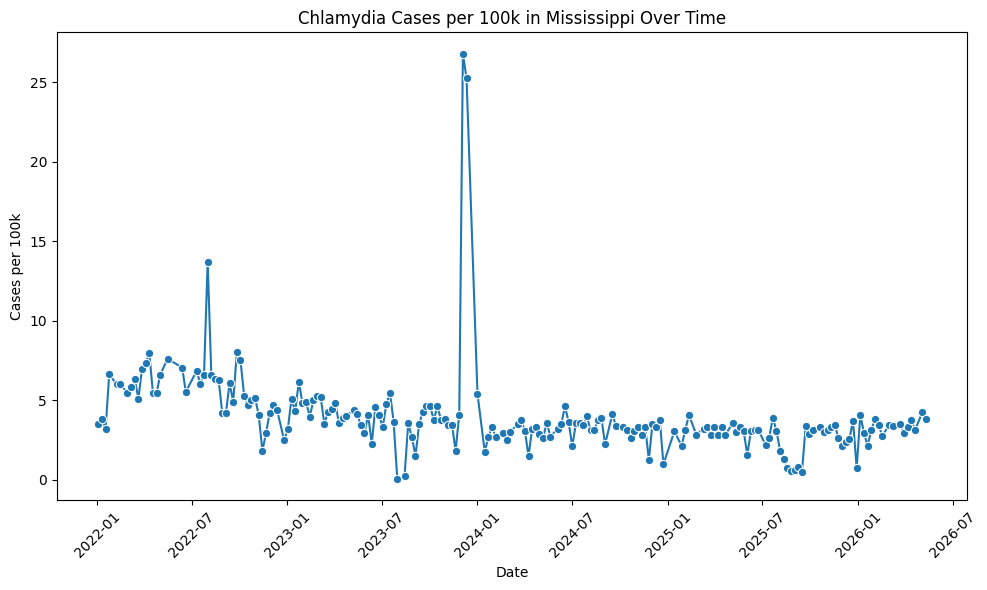

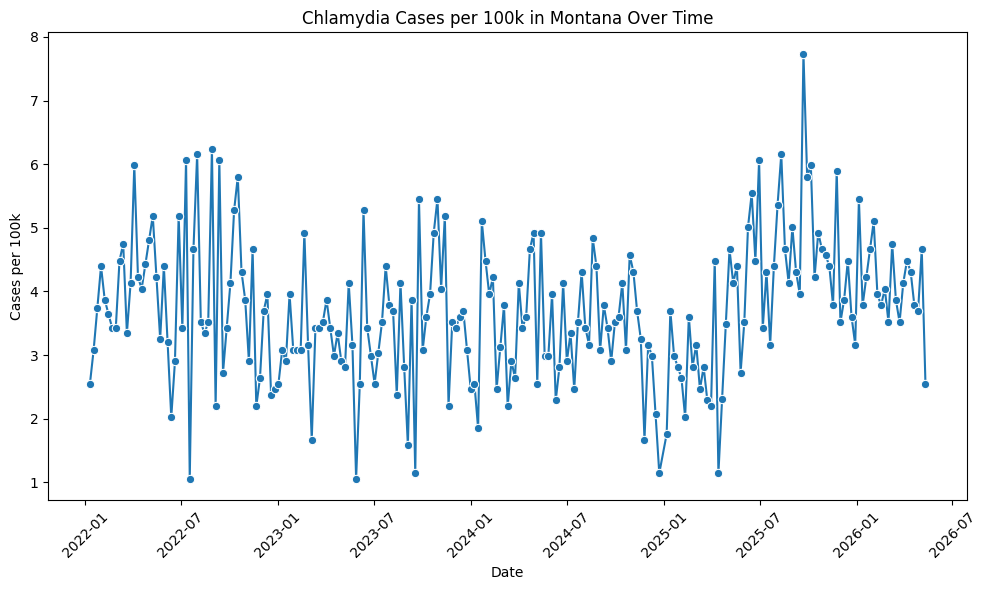

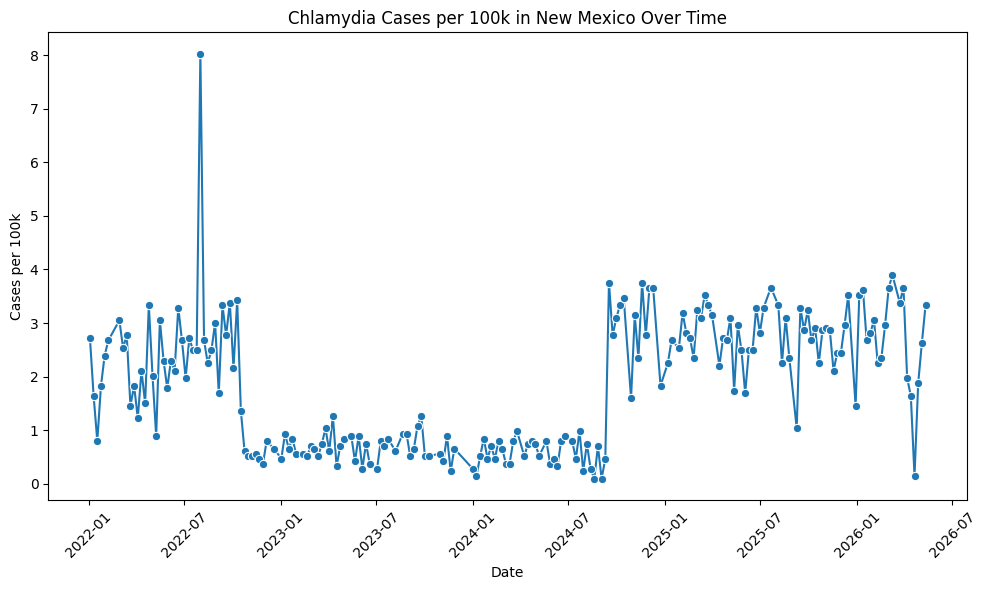

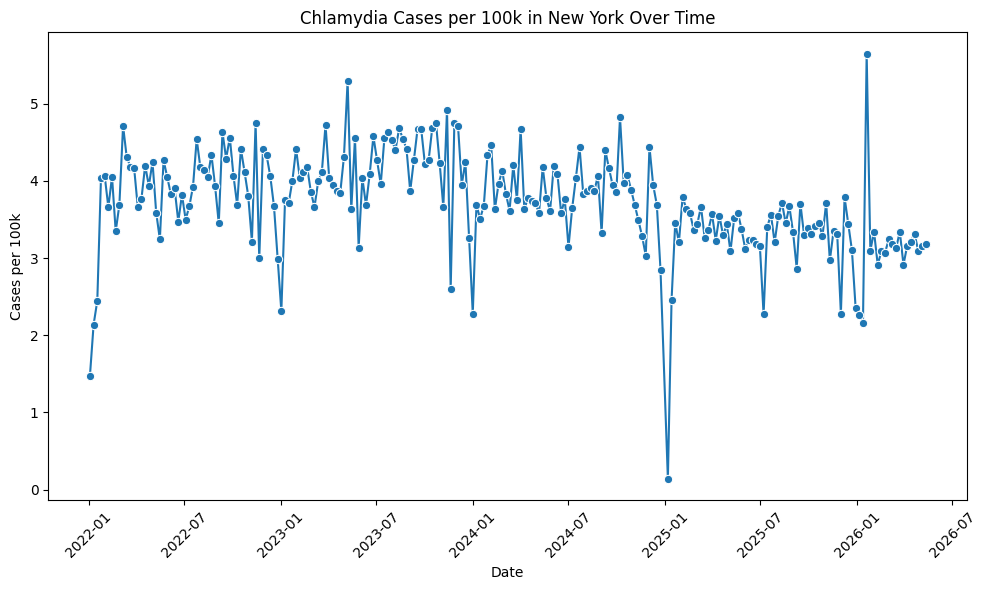

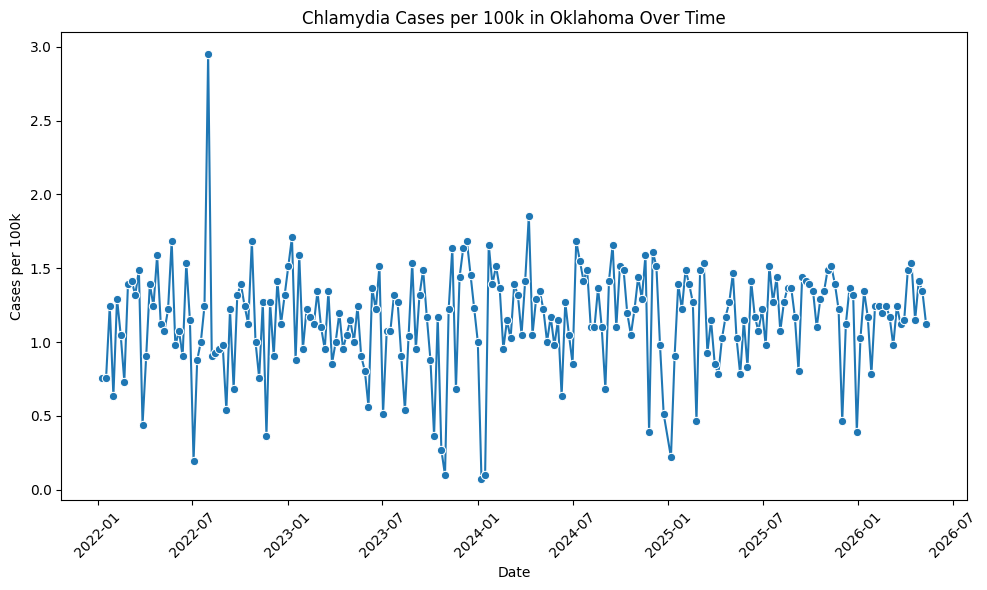

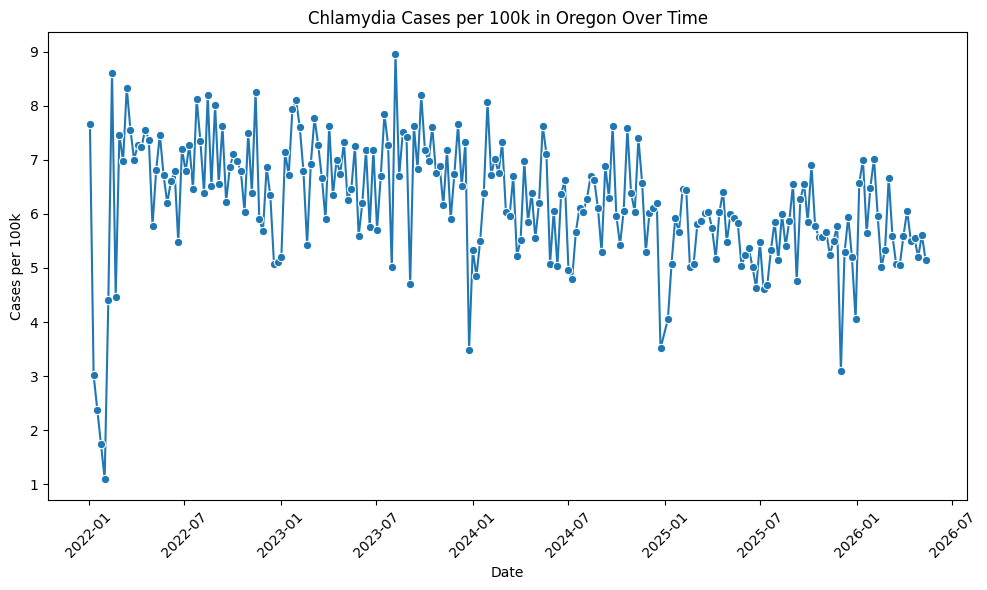

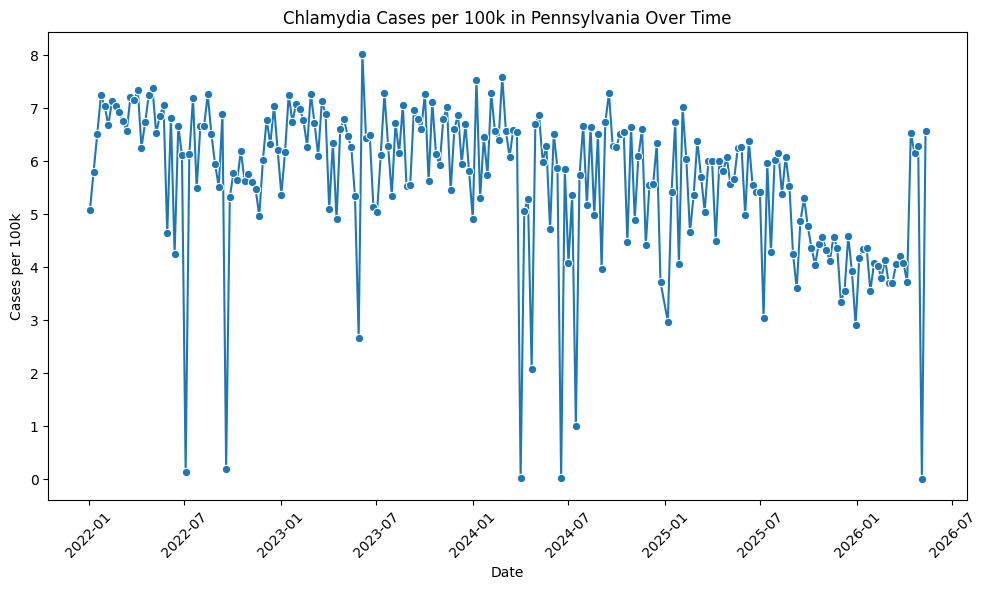

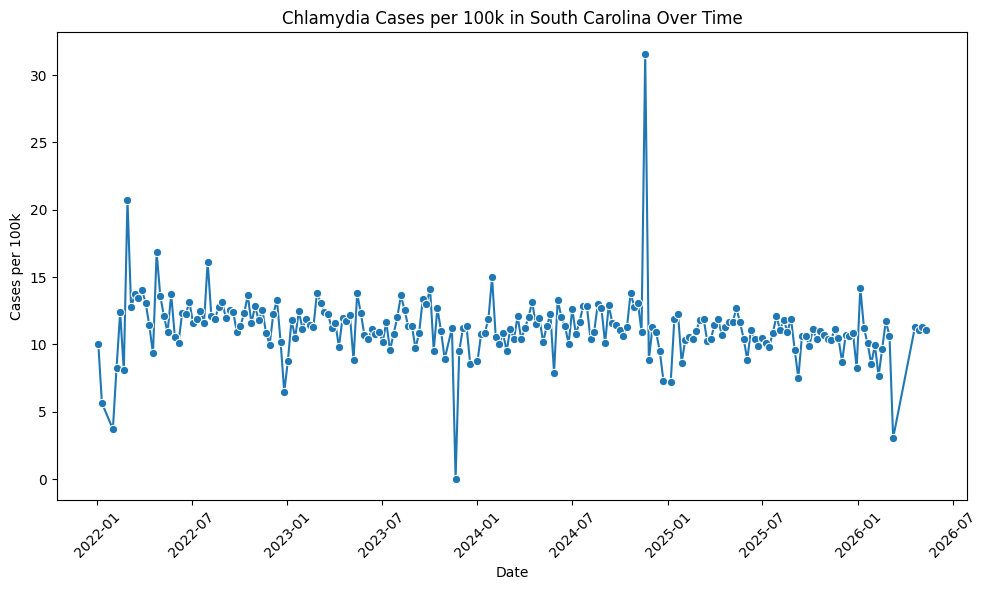

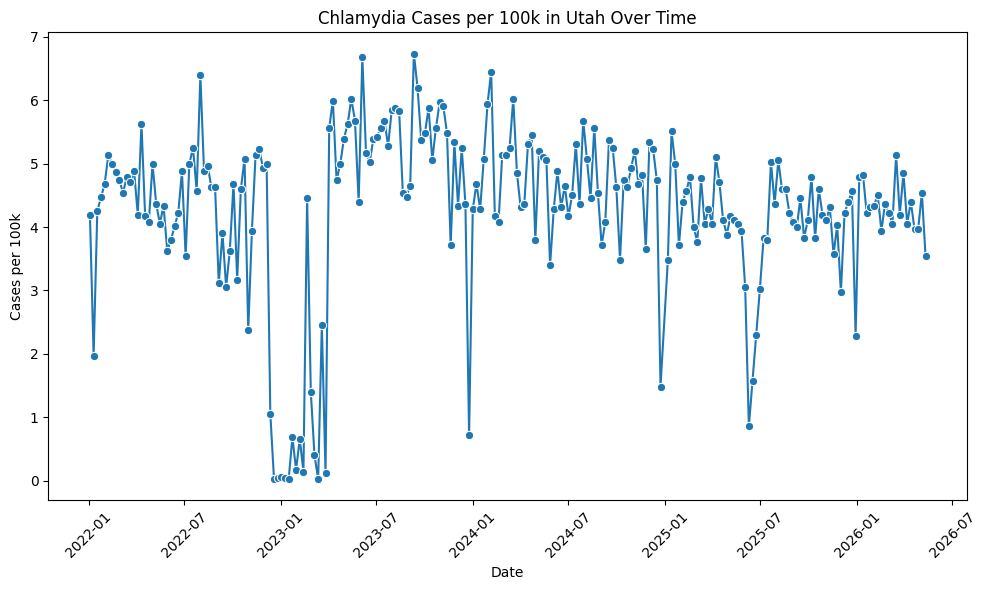

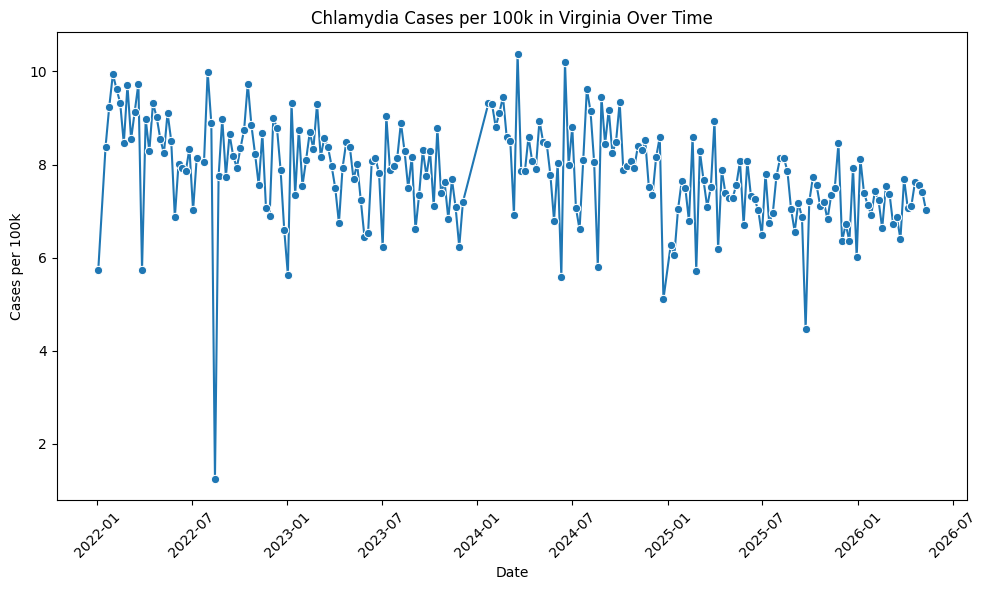

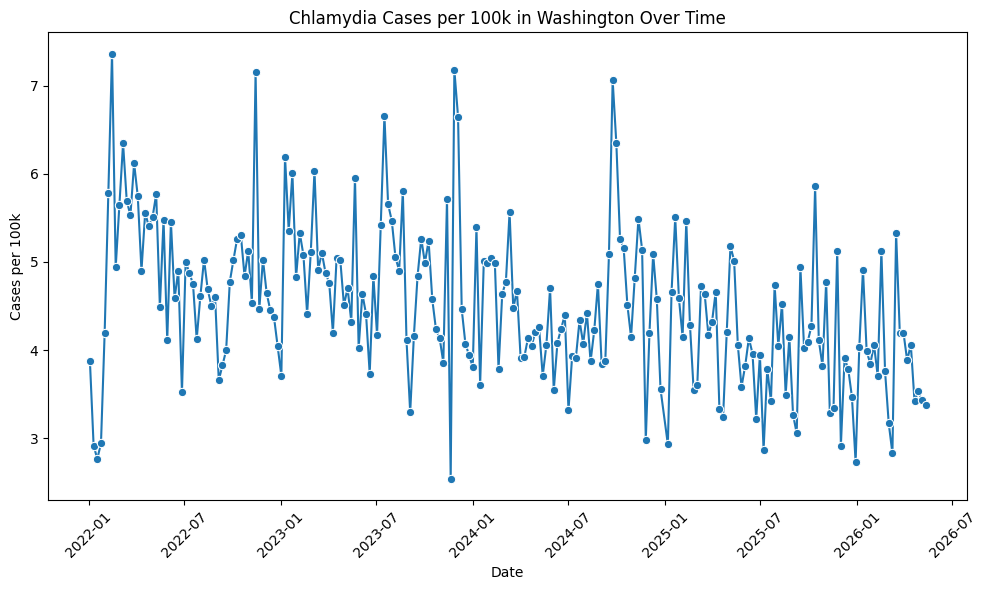

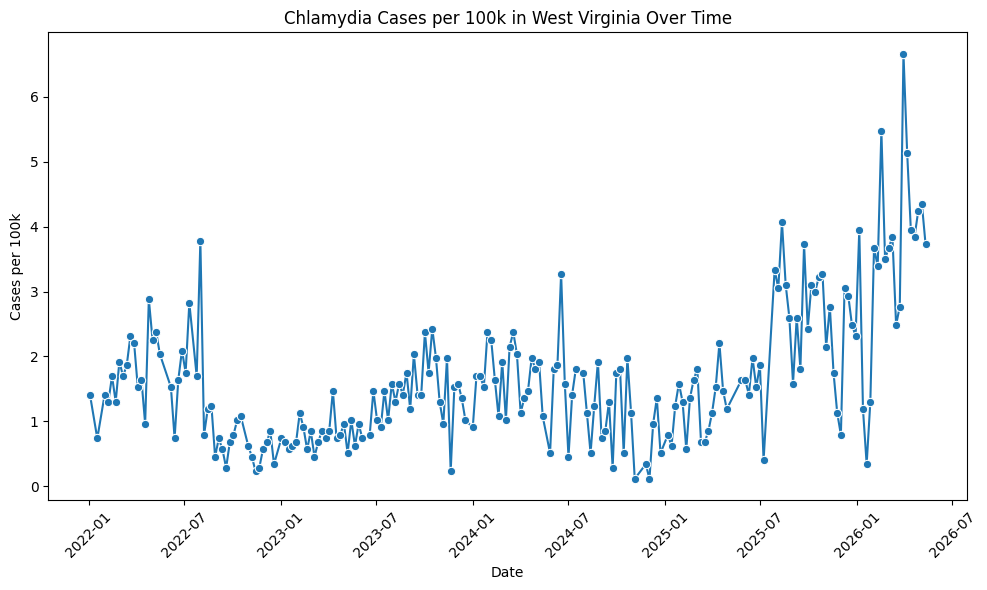

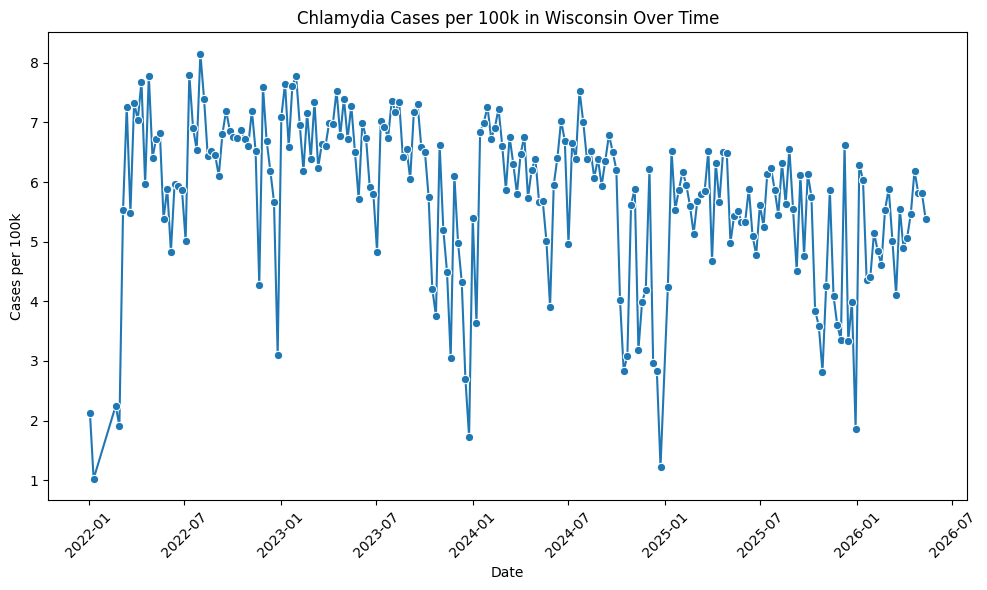

In [114]:
for st in df['state'].unique():
    plt.figure(figsize=(10,6))
    sns.lineplot(data=df[df['state'] == st], x='date', y='cases_per_100k', marker='o')
    plt.title(f'Chlamydia Cases per 100k in {st} Over Time')
    plt.xlabel('Date')
    plt.ylabel('Cases per 100k')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()